# **Sales Report Analyzer**

In [ ]:
# Step 1: Load Data from CSV

import pandas as pd
import matplotlib.pyplot as plt

def load_data(file_path):
    """Load sales data from a CSV file."""
    try:
        data = pd.read_csv(file_path)
        print("Data loaded successfully!")
        return data
    except Exception as e:
        print("Error loading data:", e)
        return None

In [ ]:
# Step 2: Clean and Preprocess Data
def clean_data(data):
    """Clean and preprocess the data."""
    print("\nCleaning Data...")

    # Fill Missing Values
    data['Product_Category'] = data['Product_Category'].fillna("Unknown")
    data = data.dropna()

    # Convert Columns
    data['Date'] = pd.to_datetime(data['Date'])
    data['Sales_Amount'] = pd.to_numeric(data['Sales_Amount'], errors='coerce')

    # Add New Columns
    data['Year_Month'] = data['Date'].dt.to_period('M')
    if 'Quantity' in data.columns and 'Price' in data.columns:
        data['Revenue'] = data['Quantity'] * data['Price']

    print("Data cleaned successfully!")
    return data


In [ ]:
# Step 3: Analyze Data and Visualize
def analyze_data(data):
    """Analyze and display insights from the data."""
    print("\n--- Sales Insights ---")

    # Total Sales by Month
    monthly_sales = data.groupby('Year_Month')['Sales_Amount'].sum()
    print("\nMonthly Sales:")
    print(monthly_sales)

    # Top 5 Products by Revenue
    if 'Revenue' in data.columns:
        top_products = data.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(5)
        print("\nTop 5 Products by Revenue:")
        print(top_products)

    # Visualize Monthly Sales
    monthly_sales.plot(kind='bar', figsize=(10, 6), color='skyblue')
    plt.title("Monthly Sales")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Step 4: Main Function
def main():
    print("Welcome to the Sales Report Analyzer!")

    # Load Data
    file_path = input("Enter the path to your sales CSV file: ")
    data = load_data(file_path)
    if data is None:
        return

    # Clean Data
    data = clean_data(data)

    # Analyze Data
    analyze_data(data)

Welcome to the Sales Report Analyzer!
Enter the path to your sales CSV file: /content/sales_data.csv
Data loaded successfully!

Cleaning Data...
Data cleaned successfully!

--- Sales Insights ---

Monthly Sales:
Year_Month
2023-01    764.80
2023-02    145.94
Freq: M, Name: Sales_Amount, dtype: float64

Top 5 Products by Revenue:
Product_Name
Jacket, Winter      99.99
Shoes, Running      79.99
Shirt, Medium       77.97
Sweatshirt, Gray    69.98
Dress, Black        64.99
Name: Revenue, dtype: float64


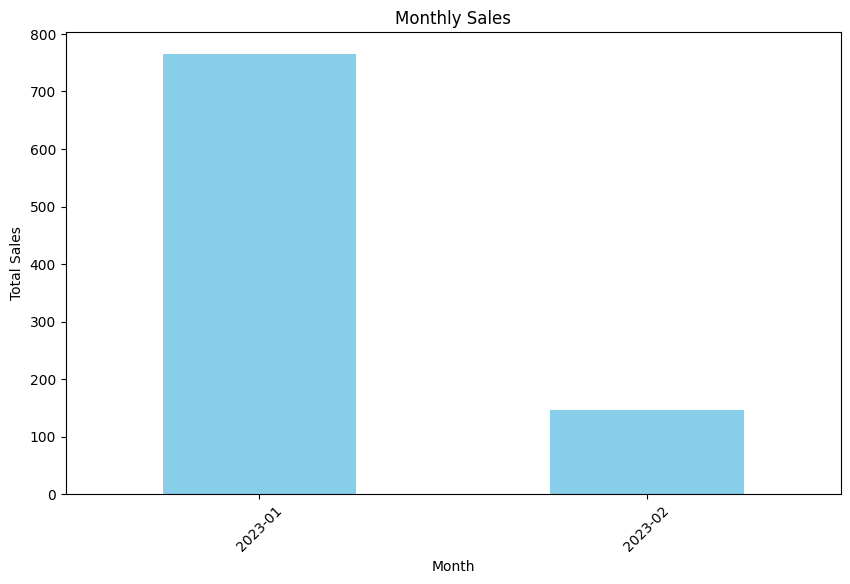

In [ ]:
# Step 5: Run Program
if __name__ == "__main__":
    main()